### Markdown Cell: Introduction & Objectives
**Objective:** Conduct agglomerative hierarchical clustering on the preprocessed white wine dataset. 

We evaluate three linkage methods: Single, Complete, and Average. Furthermore, we translate classic R functions into Python by calculating the Cophenetic Correlation Coefficient (`cor.dendlist` equivalent) and generating a correlation matrix plot of the hierarchical distance matrices (`corrplot` equivalent).

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from scipy.cluster.hierarchy import linkage, cophenet, dendrogram
from scipy.spatial.distance import pdist
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')

# Load cleaned data from Task 2 to ensure independent execution
white_clean = pd.read_csv('./processed_data/white_wine_cleaned.csv')
X_features = white_clean.drop('quality', axis=1)

# Standard Scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_features)

### Linkage Methods & Cophenetic Correlations
We compute the pairwise Euclidean distance matrix and generate hierarchical linkages. The Cophenetic Correlation Coefficient quantifies how faithfully the resulting dendrogram preserves the pairwise distances of the original unclustered data.

In [3]:
# Compute pairwise distances
Y_pdist = pdist(X_scaled, 'euclidean')

linkage_methods = ['single', 'complete', 'average']
Z_dict = {}
coph_dict = {}

for method in linkage_methods:
    Z = linkage(Y_pdist, method=method)
    c, coph_dists = cophenet(Z, Y_pdist)
    
    Z_dict[method] = Z
    coph_dict[method] = coph_dists
    print(f'Cophenetic Correlation ({method.capitalize()} Linkage): {c:.4f}')

Cophenetic Correlation (Single Linkage): 0.4374
Cophenetic Correlation (Complete Linkage): 0.4460
Cophenetic Correlation (Average Linkage): 0.5530


### Visualizing the Taxonomies (Dendrograms)
Because the dataset contains over 4000 entries, we plot truncated dendrograms showing the last 30 merged sub-clusters to ensure visual clarity while retaining taxonomic macro-structure.

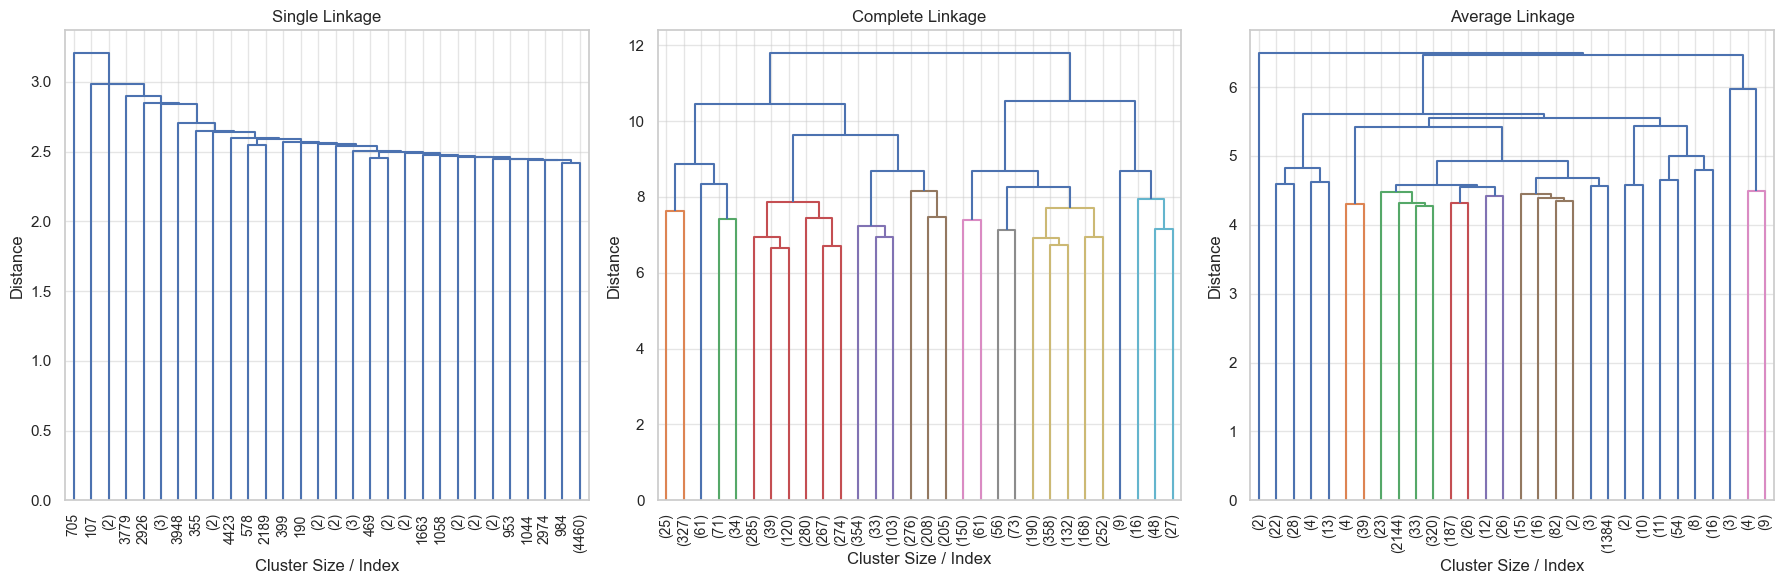

In [4]:
plt.figure(figsize=(18, 6))

for i, method in enumerate(linkage_methods):
    plt.subplot(1, 3, i+1)
    dendrogram(Z_dict[method], truncate_mode='lastp', p=30, show_leaf_counts=True, leaf_rotation=90)
    plt.title(f'{method.capitalize()} Linkage')
    plt.xlabel('Cluster Size / Index')
    plt.ylabel('Distance')

plt.tight_layout()
plt.show()

### Python Implementation of R's `cor.dendlist` & `corrplot`
In R, `cor.dendlist` computes the correlation between different cophenetic distance matrices. Here, we create a DataFrame of the flattened distance matrices and compute the Pearson correlation, visualizing it via a heatmap (`corrplot` equivalent).

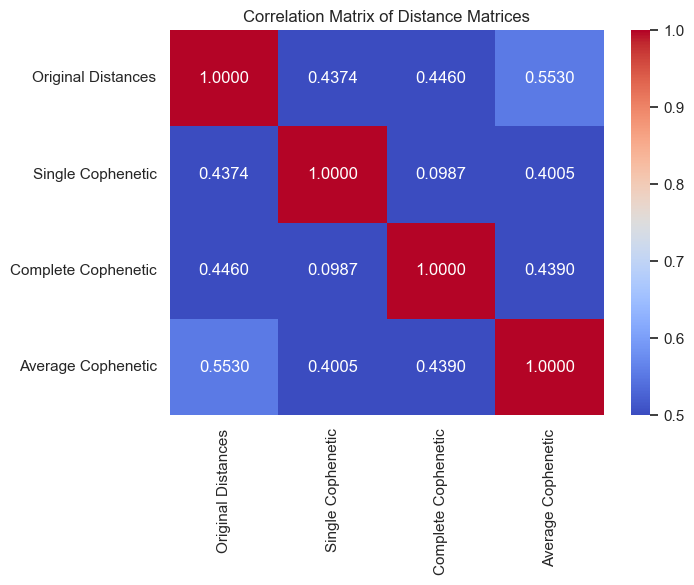

In [5]:
# Construct DataFrame of Distance Matrices
dist_df = pd.DataFrame({
    'Original Distances': Y_pdist,
    'Single Cophenetic': coph_dict['single'],
    'Complete Cophenetic': coph_dict['complete'],
    'Average Cophenetic': coph_dict['average']
})

# Pearson Correlation equivalent to cor.dendlist
corr_matrix = dist_df.corr(method='pearson')

# Heatmap visualization equivalent to corrplot
plt.figure(figsize=(7, 5))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', vmin=0.5, vmax=1.0, fmt='.4f')
plt.title('Correlation Matrix of Distance Matrices')
plt.show()